# Baseline Forecasting Models
This notebook builds naive, historical average, window average, and seasonal naive baseline forecasts for `air_so2` using the cleaned dataset.
We train on all but the last 12 observations and test on the final 12.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [7]:
# Load cleaned data
data_path = '../COS40007DataCleaning/combined_air_electricity_ipi_cleaned.csv'
df = pd.read_csv(data_path)
df.head()

,date,air_co,air_no2,air_o3,air_pm_10,air_pm_25,air_so2,electricity_exports,electricity_local,electricity_local_commercial,electricity_local_domestic,electricity_losses,electricity_total,ipi_abs_index,ipi_growth_mom_index,ipi_growth_yoy_index,ipi_abs_index_sa,ipi_growth_mom_index_sa,ipi_growth_yoy_index_sa,car_registration
0,2018-01-01,0.671,0.0078,0.015,19.14,11.43,0.0010,109.820,11845.900250,9390.080801,2455.819450,1200.383806,13156.104056,113.447,1.264,4.838,109.866,0.013,3.963,47162
1,2018-02-01,0.677,0.0069,0.024,26.06,16.75,0.0011,101.500,11091.957006,8561.415143,2530.541863,903.839625,12097.296631,101.820,-10.249,2.344,110.830,0.877,2.625,41705
2,2018-03-01,0.654,0.0074,0.019,24.84,15.61,0.0010,103.785,12244.089947,9659.320215,2584.769732,1681.104546,14028.979493,112.270,10.264,2.921,111.090,0.235,3.328,49810
3,2018-04-01,0.682,0.0075,0.019,25.64,16.34,0.0010,102.002,12018.584577,9340.784017,2677.800560,1484.235112,13604.821689,108.986,-2.925,4.977,113.036,1.752,5.918,47834
4,2018-05-01,0.671,0.0076,0.017,22.60,14.54,0.0010,142.261,12267.998390,9525.937602,2742.060788,1524.423335,13934.682725,111.631,2.426,3.502,112.183,-0.755,4.320,44598


In [8]:
def naive_forecast(train_series, horizon):
    return np.full(horizon, train_series.iloc[-1])

def historic_average_forecast(train_series, horizon):
    return np.full(horizon, train_series.mean())

def window_average_forecast(train_series, horizon, window):
    return np.full(horizon, train_series.iloc[-window:].mean())

def seasonal_naive_forecast(train_series, horizon, season_length):
    seasonal_values = train_series.iloc[-season_length:].values
    repeated = np.tile(seasonal_values, int(np.ceil(horizon / season_length)))
    return repeated[:horizon]

def evaluate_forecast(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
    }

target_columns = ['air_no2', 'electricity_local', 'ipi_abs_index_sa', 'car_registration']
horizon = 12
window = 12
season_length = 12

results_all = {}
forecast_store = {}
series_store = {}

for target_column in target_columns:
    series = df[target_column].astype(float).reset_index(drop=True)
    train = series.iloc[:-horizon].reset_index(drop=True)
    test = series.iloc[-horizon:].reset_index(drop=True)

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
    test_scaled = scaler.transform(test.values.reshape(-1, 1)).flatten()

    print(f'\nTarget series: {target_column}')
    print(f'  Test points:  {len(test)}')
    print(f'  Total points: {len(series)}')
    print(f'  Train points: {len(train)}')

    forecasts = {
        'naive': naive_forecast(pd.Series(train_scaled), horizon),
        'historic_average': historic_average_forecast(pd.Series(train_scaled), horizon),
        'window_average': window_average_forecast(pd.Series(train_scaled), horizon, window),
        'seasonal_naive': seasonal_naive_forecast(pd.Series(train_scaled), horizon, season_length),
    }

    forecast_orig = {
        name: scaler.inverse_transform(forecast.reshape(-1, 1)).flatten()
        for name, forecast in forecasts.items()
    }

    results = {}
    for name, forecast in forecast_orig.items():
        metrics = evaluate_forecast(test.values, forecast)
        results[name] = metrics

    results_df = pd.DataFrame(results).T[['mae', 'rmse', 'r2']]
    results_df.index = results_df.index.str.replace('_', ' ').str.title()
    print(results_df)

    results_all[target_column] = results_df
    forecast_store[target_column] = forecast_orig
    series_store[target_column] = {
        'test': test.values,
        'dates': np.arange(1, horizon + 1),
    }


Target series: air_no2
  Test points:  12
  Total points: 60
  Train points: 48
                       mae      rmse        r2
Naive             0.000483  0.000537 -0.533235
Historic Average  0.000342  0.000505 -0.354874
Window Average    0.000707  0.000761 -2.077179
Seasonal Naive    0.000708  0.000972 -4.020679

Target series: electricity_local
  Test points:  12
  Total points: 60
  Train points: 48
                         mae        rmse        r2
Naive             296.289030  400.862506 -0.086671
Historic Average  882.891198  910.623051 -4.607697
Window Average    807.861793  829.880881 -3.657349
Seasonal Naive    735.410073  985.110959 -5.562625

Target series: ipi_abs_index_sa
  Test points:  12
  Total points: 60
  Train points: 48
                        mae       rmse         r2
Naive              4.026333   4.745259  -2.406913
Historic Average  12.667208  12.925460 -24.277444
Window Average     8.166167   8.561287 -10.089685
Seasonal Naive     8.166167   9.176441 -11.74059

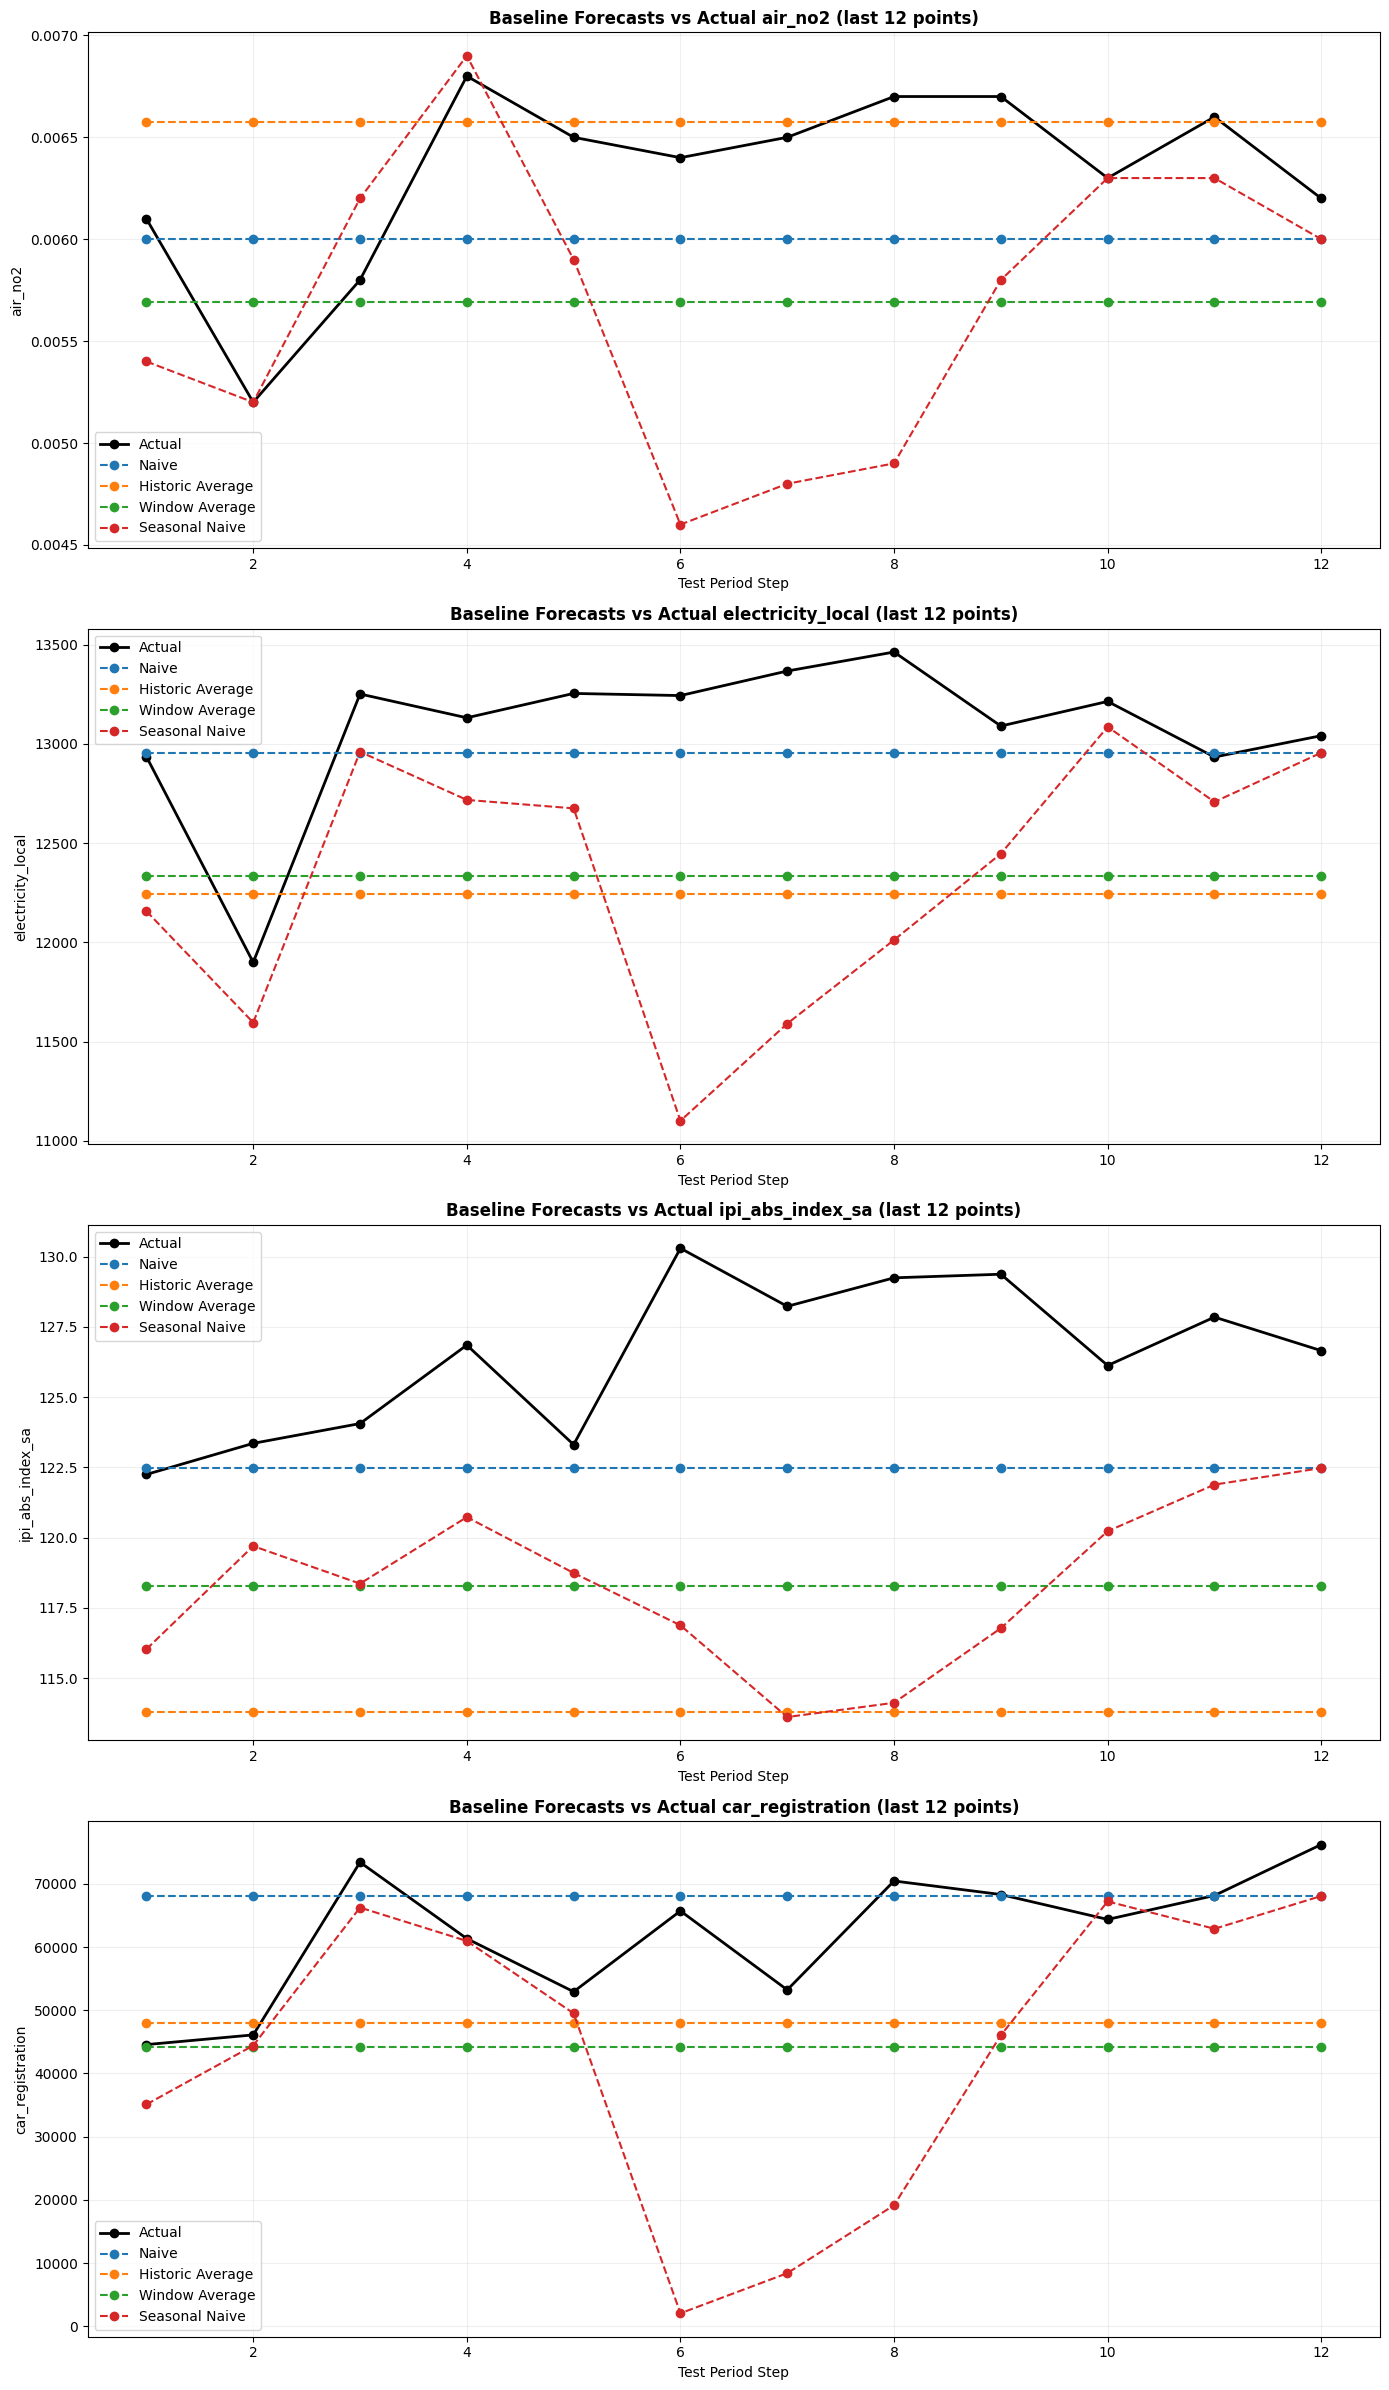

In [9]:
# Plot the actual test data and each baseline forecast for all target series
fig, axes = plt.subplots(len(target_columns), 1, figsize=(14, 6 * len(target_columns)), sharex=False)
if len(target_columns) == 1:
    axes = [axes]

for ax, target in zip(axes, target_columns):
    x = series_store[target]['dates']
    y_true = series_store[target]['test']
    ax.plot(x, y_true, marker='o', label='Actual', linewidth=2, color='black')
    for name, forecast in forecast_store[target].items():
        ax.plot(x, forecast, marker='o', linestyle='--', label=name.replace('_', ' ').title())
    ax.set_title(f'Baseline Forecasts vs Actual {target} (last {horizon} points)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Test Period Step')
    ax.set_ylabel(target)
    ax.grid(alpha=0.2)
    ax.legend()

fig.tight_layout()
plt.savefig('baseline_actual_vs_pred_all_targets.png', dpi=130, bbox_inches='tight')
plt.show()
